In [1]:
# Multivariate LSTM Time Series Prediction for Max Concurrent Tasks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.7.1
CUDA available: False


In [2]:
print("\n" + "="*60)
print("STEP 1: DATA LOADING AND FEATURE SELECTION")
print("="*60)

# Load the dataset
df = pd.read_csv('./datasets/combined_trace_processed.csv', sep=',')

# Sort by timestamp to ensure proper time series order
df['ts_submit_dt'] = pd.to_datetime(df['ts_submit_dt'])
df = df.sort_values('ts_submit_dt').reset_index(drop=True)

# Select relevant features for multivariate prediction
# Based on correlation analysis, we'll use the most informative features
feature_columns = [
    'total_queries_count',
    'aggregation_queries_count', 
    'standard_queries_count',
    'country_queries_count',
    'other_queries_count'
]

target_column = 'max_concurrent_tasks'

print(f"Dataset shape: {df.shape}")
print(f"Selected features: {feature_columns}")
print(f"Target variable: {target_column}")
print(f"Time range: {df['ts_submit_dt'].min()} to {df['ts_submit_dt'].max()}")

# Check for missing values
print(f"\nMissing values:")
for col in feature_columns + [target_column]:
    missing = df[col].isnull().sum()
    print(f"- {col}: {missing}")


STEP 1: DATA LOADING AND FEATURE SELECTION
Dataset shape: (4356, 11)
Selected features: ['total_queries_count', 'aggregation_queries_count', 'standard_queries_count', 'country_queries_count', 'other_queries_count']
Target variable: max_concurrent_tasks
Time range: 2006-09-19 22:37:54.716000 to 2009-06-26 17:00:52.088000

Missing values:
- total_queries_count: 0
- aggregation_queries_count: 0
- standard_queries_count: 0
- country_queries_count: 0
- other_queries_count: 0
- max_concurrent_tasks: 0



STEP 2: FEATURE CORRELATION ANALYSIS


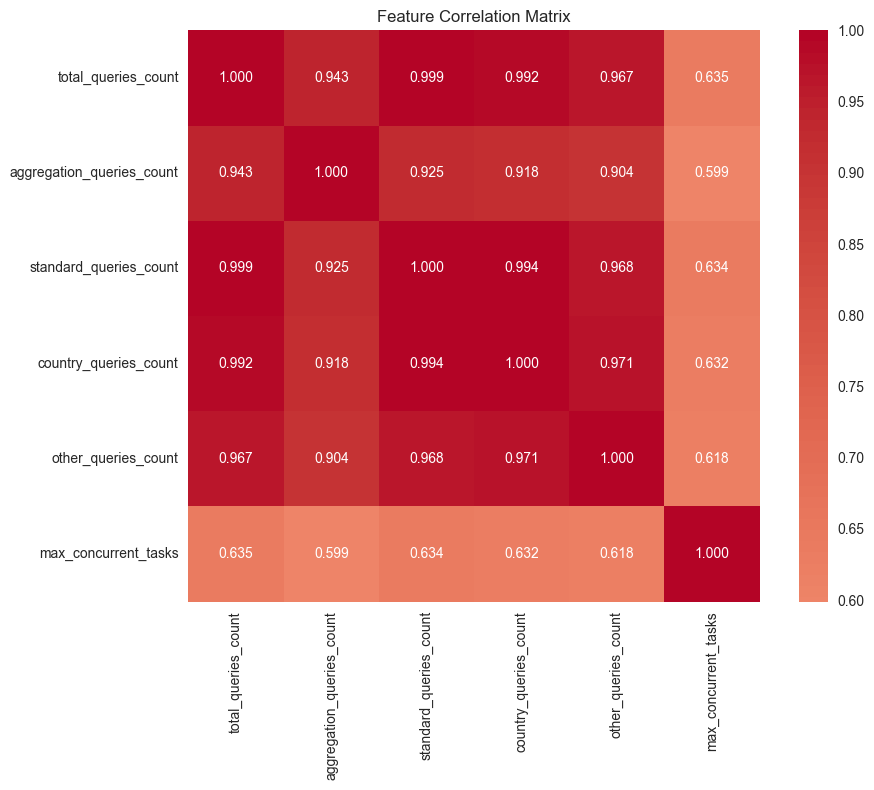


Correlations with target variable:
- total_queries_count: 0.635
- standard_queries_count: 0.634
- country_queries_count: 0.632
- other_queries_count: 0.618
- aggregation_queries_count: 0.599


In [3]:
print("\n" + "="*60)
print("STEP 2: FEATURE CORRELATION ANALYSIS")
print("="*60)

# Analyze correlations between features and target
correlation_data = df[feature_columns + [target_column]].corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlations with target
print("\nCorrelations with target variable:")
target_correlations = correlation_data[target_column].sort_values(ascending=False)
for feature, corr in target_correlations.items():
    if feature != target_column:
        print(f"- {feature}: {corr:.3f}")

In [4]:
print("\n" + "="*60)
print("STEP 3: MULTIVARIATE DATA PREPARATION")
print("="*60)

# Extract features and target
features_data = df[feature_columns].values
target_data = df[target_column].values.reshape(-1, 1)

print(f"Features shape: {features_data.shape}")
print(f"Target shape: {target_data.shape}")

# Normalize features and target separately
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_features = feature_scaler.fit_transform(features_data)
scaled_target = target_scaler.fit_transform(target_data)

print(f"\nScaled features shape: {scaled_features.shape}")
print(f"Scaled target shape: {scaled_target.shape}")

# Create sequences for multivariate LSTM
def create_multivariate_sequences(features, target, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        # Input: sequence of features
        X.append(features[i:(i+seq_length)])
        # Target: next value of target variable
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

# Define sequence length
SEQUENCE_LENGTH = 20

X, y = create_multivariate_sequences(scaled_features, scaled_target, SEQUENCE_LENGTH)

print(f"\nInput sequences shape: {X.shape}")
print(f"Target values shape: {y.shape}")
print(f"Each sequence has {SEQUENCE_LENGTH} time steps with {len(feature_columns)} features")

# Split data into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


STEP 3: MULTIVARIATE DATA PREPARATION
Features shape: (4356, 5)
Target shape: (4356, 1)

Scaled features shape: (4356, 5)
Scaled target shape: (4356, 1)

Input sequences shape: (4336, 20, 5)
Target values shape: (4336, 1)
Each sequence has 20 time steps with 5 features

Training set: 3468 samples
Test set: 868 samples


In [5]:
print("\n" + "="*60)
print("STEP 4: MULTIVARIATE LSTM MODEL")
print("="*60)

class MultivariateLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(MultivariateLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Add a fully connected layer for feature processing
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Initialize hidden states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(x, (h0, c0))
        
        # Get last output
        last_output = lstm_out[:, -1, :]
        
        # Fully connected layers
        out = self.relu(self.fc1(last_output))
        out = self.dropout(out)
        predictions = self.fc2(out)
        
        return predictions

# Model parameters
INPUT_SIZE = len(feature_columns)  # Number of features
HIDDEN_SIZE = 128
NUM_LAYERS = 4
OUTPUT_SIZE = 1

# Create model
model = MultivariateLSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
)

print(f"Model created successfully!")
print(f"Input size (features): {INPUT_SIZE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Number of layers: {NUM_LAYERS}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")


STEP 4: MULTIVARIATE LSTM MODEL
Model created successfully!
Input size (features): 5
Hidden size: 128
Number of layers: 4
Total parameters: 473729


In [6]:
print("\n" + "="*60)
print("STEP 5: TRAINING SETUP AND EXECUTION")
print("="*60)

# Dataset and DataLoader
class MultivariateTimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets and dataloaders
train_dataset = MultivariateTimeSeriesDataset(X_train, y_train)
test_dataset = MultivariateTimeSeriesDataset(X_test, y_test)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Training loop with early stopping
NUM_EPOCHS = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 15
counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs.squeeze(), batch_y.squeeze())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y.squeeze())
            val_loss += loss.item()
    
    # Calculate average losses
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

# Restore best model
model.load_state_dict(best_model_state)
print(f"\nTraining completed! Best validation loss: {best_val_loss:.6f}")


STEP 5: TRAINING SETUP AND EXECUTION
Starting training for 100 epochs...
Epoch 10: Train Loss: 0.001933, Val Loss: 0.003857
Epoch 20: Train Loss: 0.001715, Val Loss: 0.003982
Early stopping at epoch 26

Training completed! Best validation loss: 0.003830


In [7]:
print("\n" + "="*60)
print("STEP 6: MODEL EVALUATION AND PREDICTIONS")
print("="*60)

# Make predictions
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        predictions.extend(outputs.squeeze().numpy())
        actuals.extend(batch_y.squeeze().numpy())

predictions = np.array(predictions).reshape(-1, 1)
actuals = np.array(actuals).reshape(-1, 1)

# Inverse transform to original scale
predictions_original = target_scaler.inverse_transform(predictions)
actuals_original = target_scaler.inverse_transform(actuals)

# Calculate metrics
mse = mean_squared_error(actuals_original, predictions_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_original, predictions_original)

print(f"Model Performance Metrics:")
print(f"- Mean Squared Error (MSE): {mse:.2f}")
print(f"- Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"- Mean Absolute Error (MAE): {mae:.2f}")

# Calculate accuracy metrics
mape = np.mean(np.abs((actuals_original - predictions_original) / actuals_original)) * 100
print(f"- Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


STEP 6: MODEL EVALUATION AND PREDICTIONS
Model Performance Metrics:
- Mean Squared Error (MSE): 4.98
- Root Mean Squared Error (RMSE): 2.23
- Mean Absolute Error (MAE): 1.14
- Mean Absolute Percentage Error (MAPE): 45.05%



STEP 7: RESULTS VISUALIZATION


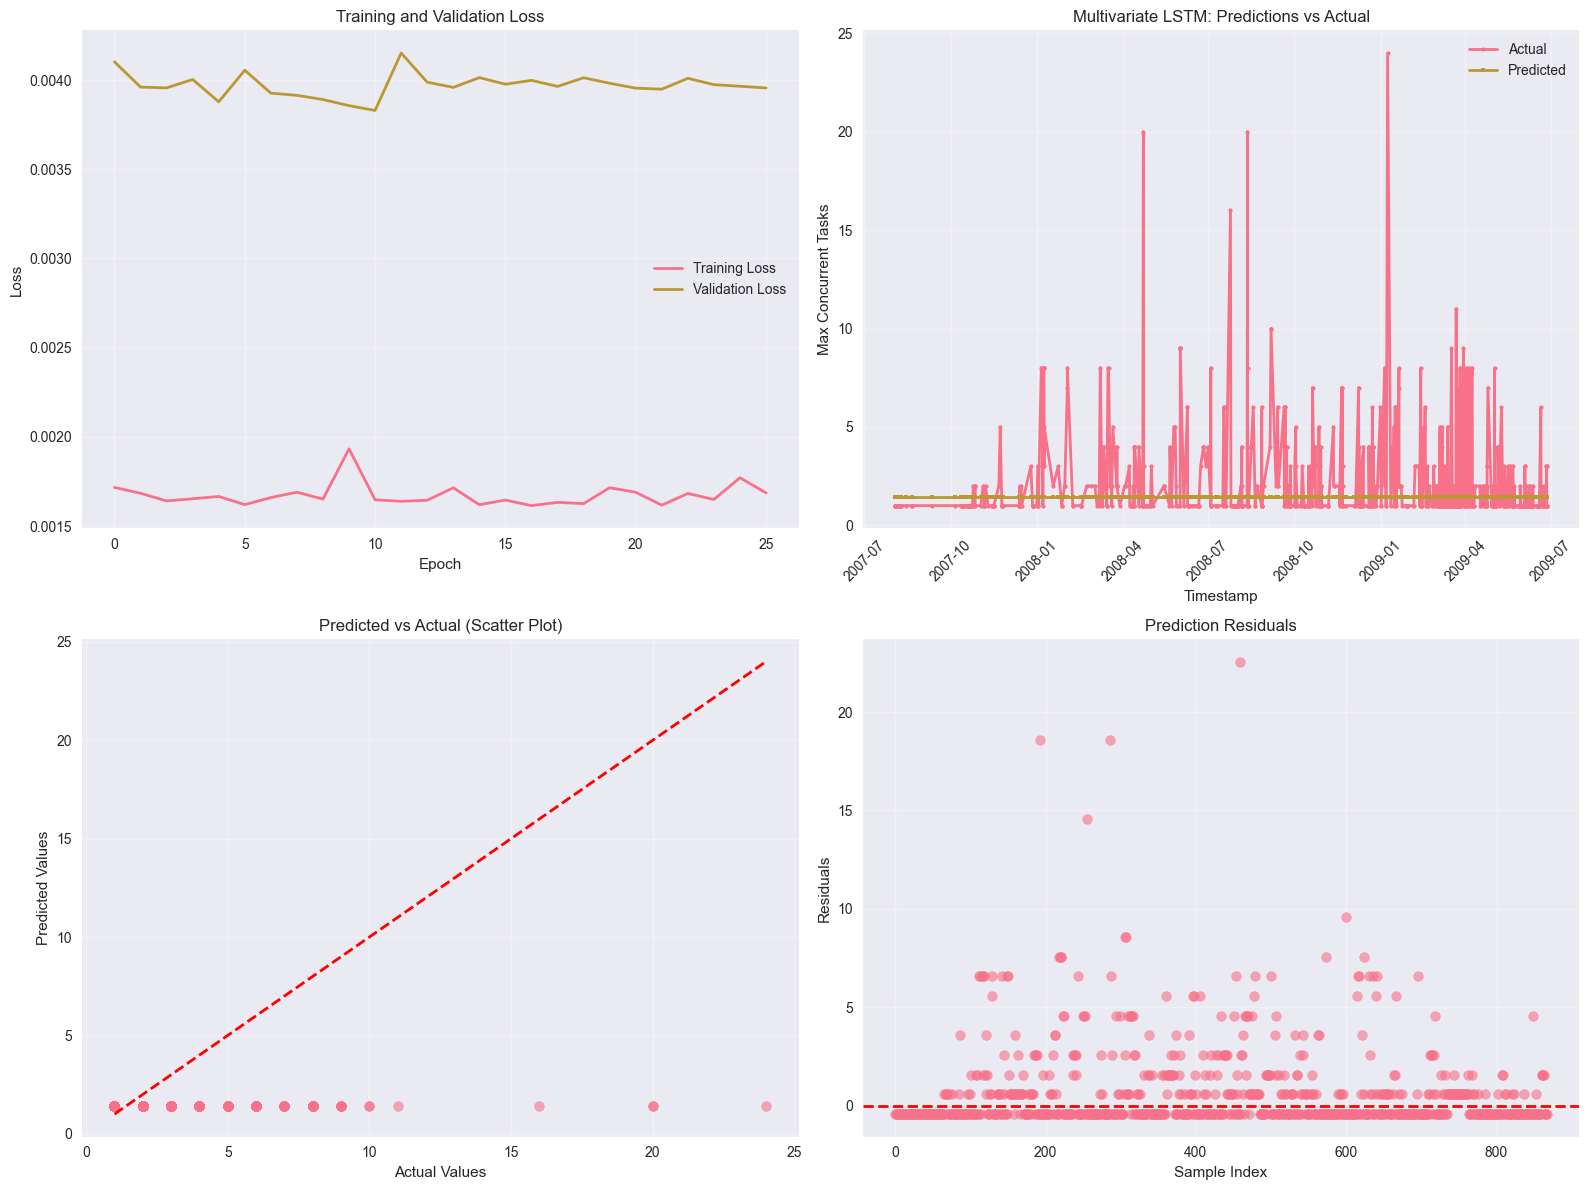


Feature Importance (based on correlations):
- total_queries_count: 0.635
- aggregation_queries_count: 0.599
- standard_queries_count: 0.634
- country_queries_count: 0.632
- other_queries_count: 0.618


In [8]:
print("\n" + "="*60)
print("STEP 7: RESULTS VISUALIZATION")
print("="*60)

# Get timestamps for test data
test_start_idx = train_size + SEQUENCE_LENGTH
test_timestamps = df['ts_submit_dt'].iloc[test_start_idx:test_start_idx + len(predictions)]

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training history
axes[0, 0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual over time
axes[0, 1].plot(test_timestamps, actuals_original, 'o-', label='Actual', linewidth=2, markersize=3)
axes[0, 1].plot(test_timestamps, predictions_original, 's-', label='Predicted', linewidth=2, markersize=3)
axes[0, 1].set_title('Multivariate LSTM: Predictions vs Actual')
axes[0, 1].set_xlabel('Timestamp')
axes[0, 1].set_ylabel('Max Concurrent Tasks')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter plot
axes[1, 0].scatter(actuals_original, predictions_original, alpha=0.6, s=50)
axes[1, 0].plot([actuals_original.min(), actuals_original.max()], 
               [actuals_original.min(), actuals_original.max()], 'r--', linewidth=2)
axes[1, 0].set_xlabel('Actual Values')
axes[1, 0].set_ylabel('Predicted Values')
axes[1, 0].set_title('Predicted vs Actual (Scatter Plot)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals
residuals = actuals_original - predictions_original
axes[1, 1].scatter(range(len(residuals)), residuals, alpha=0.6, s=50)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Prediction Residuals')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance analysis
print("\nFeature Importance (based on correlations):")
for i, feature in enumerate(feature_columns):
    corr = correlation_data.loc[feature, target_column]
    print(f"- {feature}: {corr:.3f}")